<a href="https://colab.research.google.com/github/NelsonOyarzo/Ejercicio02/blob/main/Ejercicio02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importar librerías

In [1]:
# Importamos pandas para manipulación de datos
import pandas as pd

# Importamos matplotlib para crear gráficos
import matplotlib.pyplot as plt

Cargar archivo CSV

In [2]:
# Cargamos el archivo CSV en un DataFrame
df = pd.read_csv('boston.csv')

# Mostramos las primeras filas para verificar que cargó correctamente
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Análisis estadístico descriptivo

In [3]:
# Generamos estadísticas descriptivas generales
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Explicación en Markdown

## Interpretación estadística

El dataset contiene 506 registros.

### Variable MEDV (precio medio de viviendas)
- Promedio: 22.53
- Mediana: 21.20
- Valor mínimo: 5.00
- Valor máximo: 50.00

Esto indica una dispersión importante en el valor de las viviendas.

### Variable RM (habitaciones)
- Promedio: 6.28 habitaciones por vivienda

En general, las casas tienen entre 5 y 7 habitaciones.

Buscar valores nulos

In [4]:
# Revisamos si existen datos faltantes
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


Detección de Outliers (IQR)

In [10]:
# Calculamos primer cuartil
Q1 = df['MEDV'].quantile(0.25)

# Calculamos tercer cuartil
Q3 = df['MEDV'].quantile(0.75)

# Calculamos rango intercuartílico
IQR = Q3 - Q1

# Definimos límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtramos outliers
outliers = df[(df['MEDV'] < limite_inferior) | (df['MEDV'] > limite_superior)]

outliers

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
97,0.12083,0.0,2.89,0,0.4450,8.069,76.0,3.4952,2,276.0,18.0,396.90,4.21,38.7
98,0.08187,0.0,2.89,0,0.4450,7.820,36.9,3.4952,2,276.0,18.0,393.53,3.57,43.8
157,1.22358,0.0,19.58,0,0.6050,6.943,97.4,1.8773,5,403.0,14.7,363.43,4.59,41.3
161,1.46336,0.0,19.58,0,0.6050,7.489,90.8,1.9709,5,403.0,14.7,374.43,1.73,50.0
162,1.83377,0.0,19.58,1,0.6050,7.802,98.2,2.0407,5,403.0,14.7,389.61,1.92,50.0
163,1.51902,0.0,19.58,1,0.6050,8.375,93.9,2.1620,5,403.0,14.7,388.45,3.32,50.0
166,2.01019,0.0,19.58,0,0.6050,7.929,96.2,2.0459,5,403.0,14.7,369.30,3.70,50.0
179,0.05780,0.0,2.46,0,0.4880,6.980,58.4,2.8290,3,193.0,17.8,396.90,5.04,37.2
180,0.06588,0.0,2.46,0,0.4880,7.765,83.3,2.7410,3,193.0,17.8,395.56,7.56,39.8
182,0.09103,0.0,2.46,0,0.4880,7.155,92.2,2.7006,3,193.0,17.8,394.12,4.82,37.9


Explicación Markdown de outliers

## Detección de Outliers

Se utiliza el método IQR (Rango Intercuartílico).

### Fórmula aplicada

IQR = Q3 - Q1

Luego se calculan límites:

- límite inferior
- límite superior

Los valores fuera de estos límites son considerados valores atípicos.

Estos casos pueden representar viviendas con precios excepcionalmente altos o bajos.

Boxplot de outliers

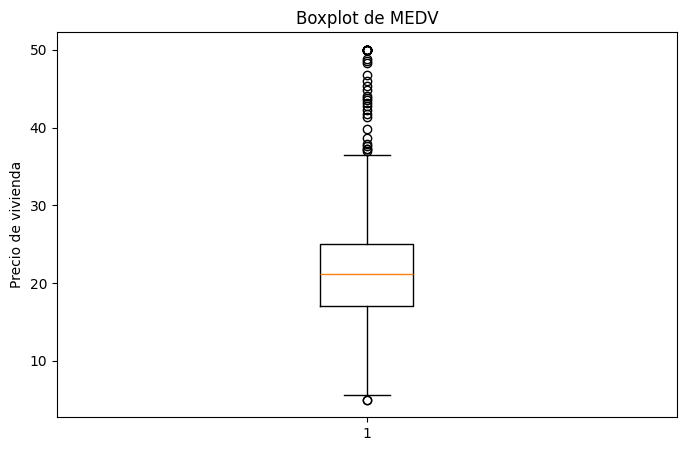

In [11]:
# Graficamos boxplot de MEDV
plt.figure(figsize=(8,5))
plt.boxplot(df['MEDV'])
plt.title('Boxplot de MEDV')
plt.ylabel('Precio de vivienda')
plt.show()

Markdown boxplot

## Interpretación del boxplot

El boxplot permite observar:

- mediana
- dispersión
- valores extremos

Los puntos fuera de la caja representan outliers.

Histograma

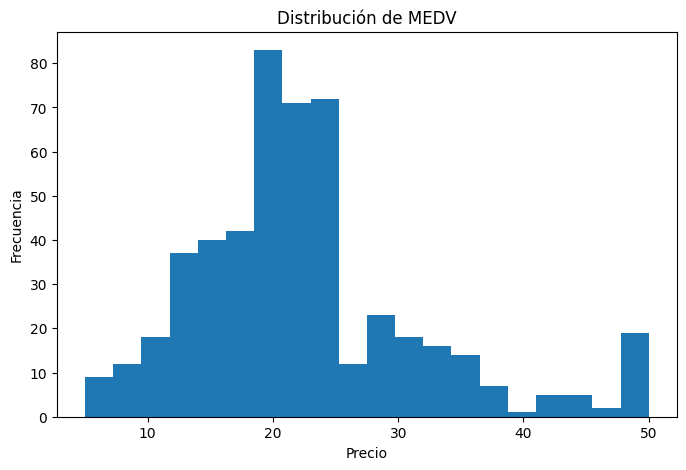

In [12]:
# Histograma de distribución de precios
plt.figure(figsize=(8,5))
plt.hist(df['MEDV'], bins=20)
plt.title('Distribución de MEDV')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

Markdown histograma

## Distribución de datos

El histograma muestra cómo se distribuyen los precios.

Se observa concentración en ciertos rangos de precio y menor frecuencia en valores extremos.

Relación entre habitaciones y precio

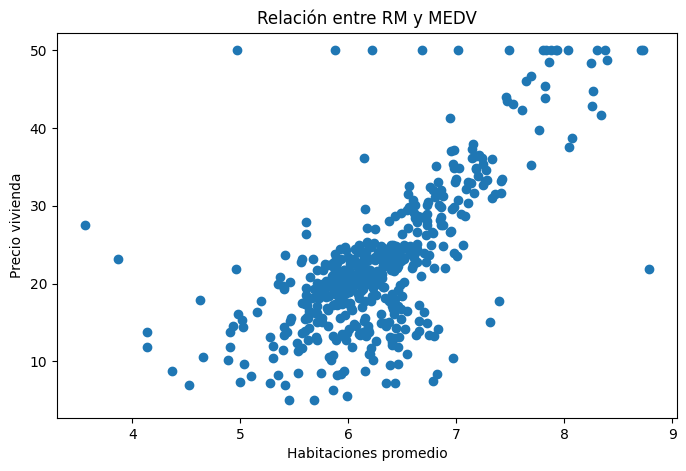

In [13]:
# Relación entre número de habitaciones y precio
plt.figure(figsize=(8,5))
plt.scatter(df['RM'], df['MEDV'])
plt.title('Relación entre RM y MEDV')
plt.xlabel('Habitaciones promedio')
plt.ylabel('Precio vivienda')
plt.show()

Markdown relación

## Relación entre variables

La variable RM representa número promedio de habitaciones.

Se observa tendencia positiva:

- a mayor número de habitaciones,
- mayor valor de vivienda.

# Conclusión general

El análisis muestra:

- existencia de outliers,
- distribución no uniforme,
- relación positiva entre habitaciones y precio.

Esto permite comprender mejor el comportamiento del mercado inmobiliario representado en el dataset.